1. ИМПОРТ БИБЛИОТЕК

In [1]:
import os
import json
import time
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

2. НАСТРОЙКА УСТРОЙСТВА

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


3. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

Mounted at /content/drive
File size: 342.70 MB
Archive extracted successfully
Found 1 HDF5 file(s)
File: food_c101_n1000_r384x384x3.h5
Loaded 1000 images
Number of classes: 101
Classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']...


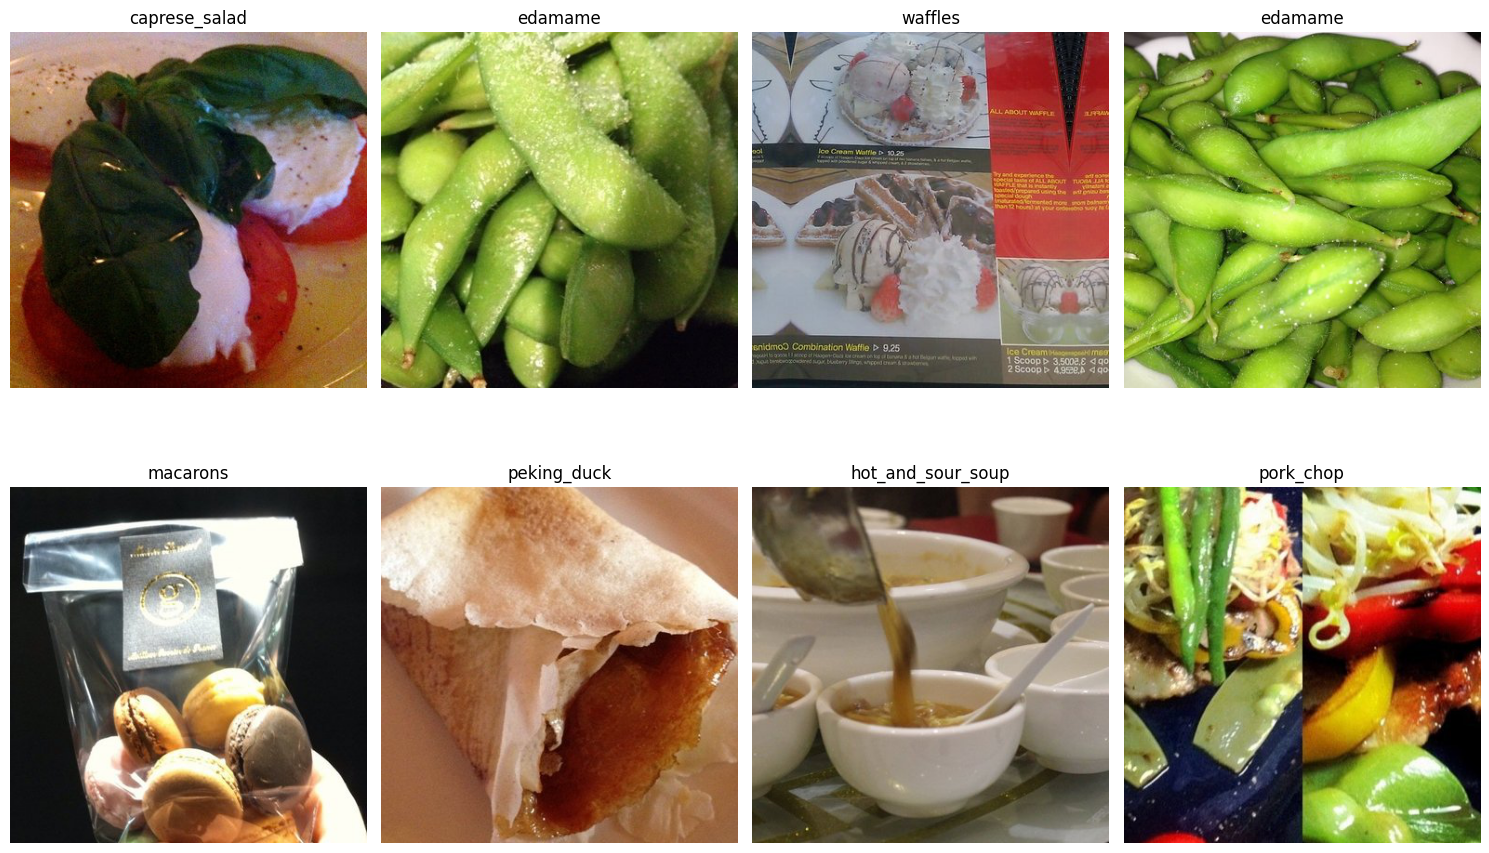

In [3]:
# Монтирование Google Drive (для Colab)
from google.colab import drive
drive.mount('/content/drive')

# Загрузка датасета с Google Drive
!cp "/content/drive/MyDrive/food_c101_n1000_r384x384x3.h5.zip" "./"

# Проверка и распаковка
if os.path.exists('food_c101_n1000_r384x384x3.h5.zip'):
    print(f"File size: {os.path.getsize('food_c101_n1000_r384x384x3.h5.zip') / 1024**2:.2f} MB")
    import zipfile
    with zipfile.ZipFile('food_c101_n1000_r384x384x3.h5.zip', 'r') as zip_ref:
        zip_ref.extractall('./food_dataset')
    print("Archive extracted successfully")

# Поиск HDF5 файла
h5_files = []
for root, dirs, files in os.walk('./food_dataset'):
    for file in files:
        if file.endswith('.h5'):
            h5_files.append(os.path.join(root, file))

if h5_files:
    print(f"Found {len(h5_files)} HDF5 file(s)")
    h5_path = h5_files[0]
    print(f"File: {os.path.basename(h5_path)}")

# Загрузка данных из HDF5
with h5py.File(h5_path, 'r') as f:
    images = f['images'][:]
    category = f['category'][:]
    category_names = f['category_names'][:]

# Преобразование one-hot в индексы
labels = np.argmax(category, axis=1)
class_names = [name.decode('utf-8') for name in category_names]

print(f"Loaded {len(images)} images")
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names[:5]}...")

# Визуализация примеров
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

 4. ПОДГОТОВКА ДАННЫХ: РАЗДЕЛЕНИЕ И СОХРАНЕНИЕ

In [4]:
# Стратифицированное разбиение на train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, test_size=0.15, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} images")
print(f"Validation: {len(X_val)} images")
print(f"Test: {len(X_test)} images")

# Сохранение предобработанных данных
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Data saved to .npy files and class_names.json")

Train: 700 images
Validation: 150 images
Test: 150 images
Data saved to .npy files and class_names.json


5. СОЗДАНИЕ DATASET И DATALOADER

In [5]:
class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Трансформации с аугментацией
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка данных
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

train_dataset = FoodDataset(X_train, y_train, transform=train_transform)
val_dataset = FoodDataset(X_val, y_val, transform=val_transform)
test_dataset = FoodDataset(X_test, y_test, transform=val_transform)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 44
Validation batches: 10
Test batches: 10


6. ОБУЧЕНИЕ МОДЕЛЕЙ

In [6]:
def create_model(model_name, num_classes=101):
    if model_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights='IMAGENET1K_V1')
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

def train_model(model, model_name, train_loader, val_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_accuracies = []
    best_val_acc = 0.0

    print(f"\nTraining model: {model_name}")

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), f'best_model_{model_name}.pth')

        print(f'Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

    print(f'Training of {model_name} completed. Best Val Accuracy: {best_val_acc:.2f}%')

    return {
        'model_name': model_name,
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc
    }

# Обучение всех архитектур
models_to_train = ['resnet18', 'resnet50', 'densenet121', 'efficientnet_b0', 'mobilenet_v2']
training_results = {}

for model_name in models_to_train:
    print(f"\nCreating model: {model_name}")
    model = create_model(model_name)

    start_time = time.time()
    history = train_model(model, model_name, train_loader, val_loader, epochs=10)
    training_time = time.time() - start_time

    history['training_time'] = training_time
    training_results[model_name] = history

    print(f"Training time: {training_time:.2f} seconds")

    del model
    torch.cuda.empty_cache()

print("\nAll models have been trained successfully!")


Creating model: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]



Training model: resnet18


Epoch 1/10: 100%|██████████| 44/44 [02:19<00:00,  3.18s/it]


Epoch 1/10: Train Loss: 5.0408, Val Accuracy: 1.33%


...

Epoch 8/10: Train Loss: 3.5121, Val Accuracy: 14.00%


Epoch 9/10: 100%|██████████| 44/44 [01:12<00:00,  1.65s/it]


Epoch 9/10: Train Loss: 3.3329, Val Accuracy: 12.00%


Epoch 10/10: 100%|██████████| 44/44 [01:12<00:00,  1.65s/it]


Epoch 10/10: Train Loss: 3.0948, Val Accuracy: 11.33%
Training of mobilenet_v2 completed. Best Val Accuracy: 14.00%
Training time: 784.74 seconds

All models have been trained successfully!


7. АНАЛИЗ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ


Comparative Results:
          Model  Validation Accuracy (%)  Training Time (s)
       resnet18                     8.67            1468.26
       resnet50                     4.67            3829.63
    densenet121                    13.33            2993.22
efficientnet_b0                    28.00            1178.17
   mobilenet_v2                    14.00             784.74


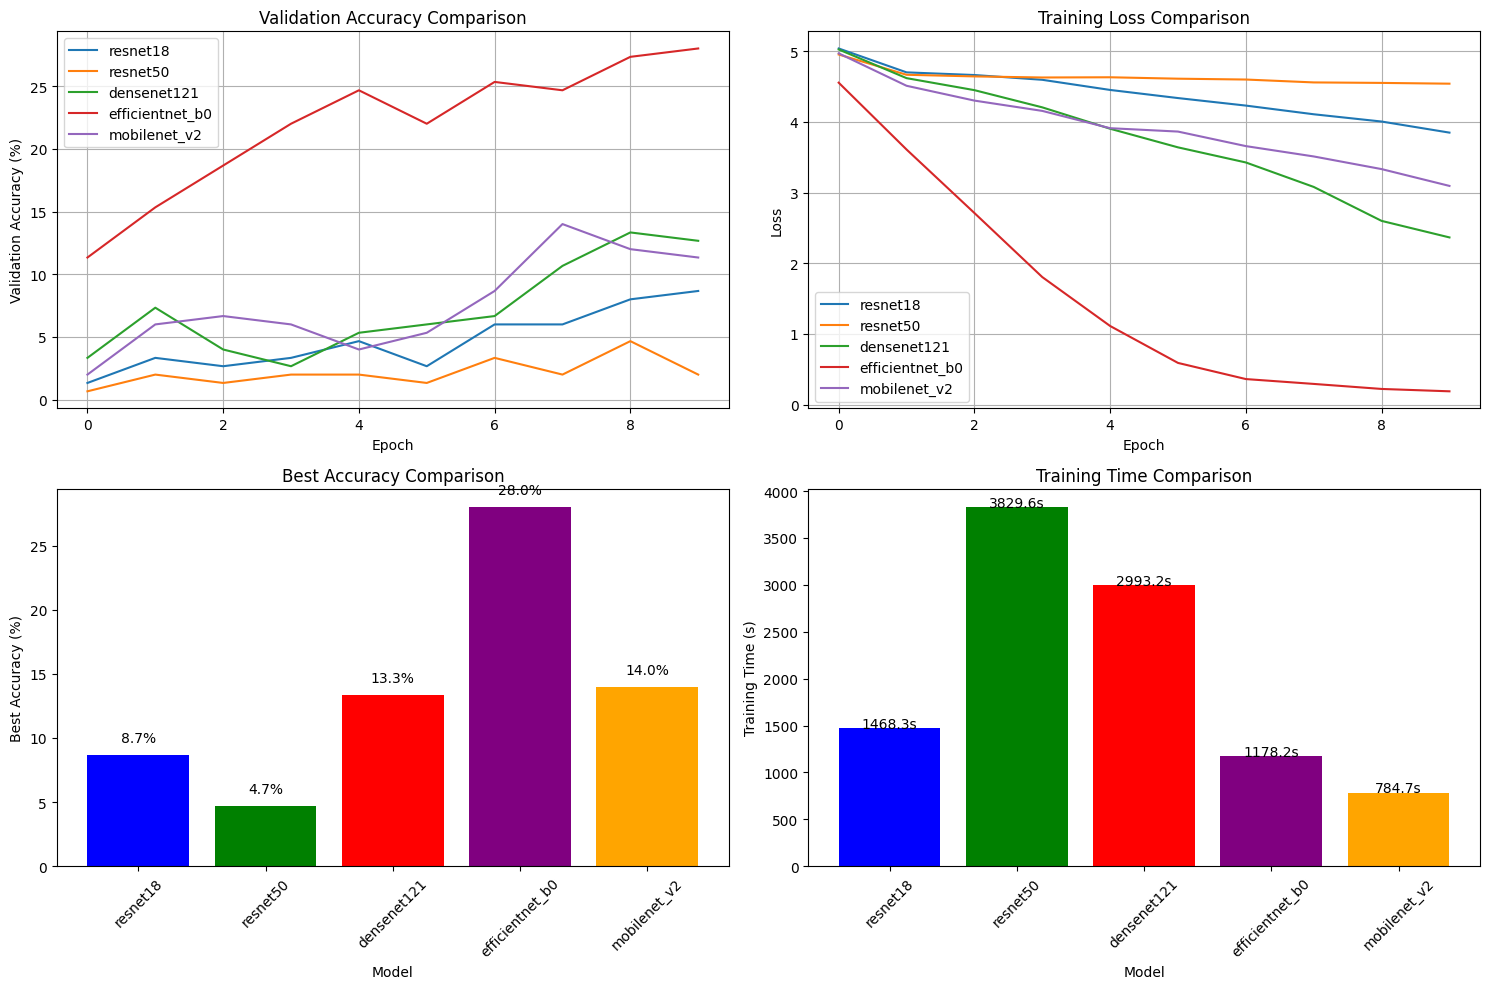

In [7]:
results_table = []
for model_name, history in training_results.items():
    results_table.append({
        'Model': model_name,
        'Validation Accuracy (%)': round(history['best_val_acc'], 2),
        'Training Time (s)': round(history['training_time'], 2)
    })

df_results = pd.DataFrame(results_table)
print("\nComparative Results:")
print(df_results.to_string(index=False))

# Визуализация результатов
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
for model_name, history in training_results.items():
    plt.plot(history['val_accuracies'], label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for model_name, history in training_results.items():
    plt.plot(history['train_losses'], label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
models = [h['model_name'] for h in training_results.values()]
accuracies = [h['best_val_acc'] for h in training_results.values()]
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Model')
plt.ylabel('Best Accuracy (%)')
plt.title('Best Accuracy Comparison')
plt.xticks(rotation=45)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.subplot(2, 2, 4)
times = [h['training_time'] for h in training_results.values()]
plt.bar(models, times, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Model')
plt.ylabel('Training Time (s)')
plt.title('Training Time Comparison')
plt.xticks(rotation=45)
for i, v in enumerate(times):
    plt.text(i, v + 1, f'{v:.1f}s', ha='center')

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150)
plt.show()

In [9]:
def create_model(model_name, num_classes=101):
    from torchvision import models  # Локальный импорт гарантирует свежесть

    if model_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights='IMAGENET1K_V1')
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

8. ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ

In [10]:
# Определение лучшей модели
best_model_name = max(training_results, key=lambda x: training_results[x]['best_val_acc'])
print(f"\nBest model: {best_model_name}")
print(f"Validation accuracy: {training_results[best_model_name]['best_val_acc']:.2f}%")

# Загрузка лучшей модели
best_model = create_model(best_model_name)
best_model.load_state_dict(torch.load(f'best_model_{best_model_name}.pth'))
best_model = best_model.to(device)
best_model.eval()

# Оценка на тестовых данных
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating on test data'):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

print("\nEvaluating best model on test set...")
test_preds, test_labels = evaluate_model(best_model, test_loader)

# Расчет метрик
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, average='macro')
recall = recall_score(test_labels, test_preds, average='macro')
f1 = f1_score(test_labels, test_preds, average='macro')

print(f"\nTest Results ({best_model_name}):")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

# Сохранение метрик
test_metrics = {
    'model': best_model_name,
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1_score': round(f1, 4),
    'test_size': len(test_labels)
}

with open('test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=4)

# Сохранение модели для демо-приложения
torch.save(best_model.state_dict(), 'final_best_model.pth')
print("Model saved as 'final_best_model.pth'")


Best model: efficientnet_b0
Validation accuracy: 28.00%

Evaluating best model on test set...


Evaluating on test data: 100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


Test Results (efficientnet_b0):
  Accuracy:  0.2867 (28.67%)
  Precision: 0.2185
  Recall:    0.2756
  F1-score:  0.2261
Model saved as 'final_best_model.pth'


9. ДЕМОНСТРАЦИОННОЕ ПРИЛОЖЕНИЕ (GRADIO)

In [11]:
!pip install gradio -q

import gradio as gr

# Загрузка данных для демо
with open('class_names.json', 'r') as f:
    class_names = json.load(f)

def predict_image(image):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = best_model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0] * 100
        top5_prob, top5_idx = torch.topk(probabilities, 5)

    result = []
    for idx, prob in zip(top5_idx, top5_prob):
        class_name = class_names[idx].replace('_', ' ').title()
        result.append((class_name, prob.item()))

    return result

def format_prediction(prediction):
    if not prediction:
        return "Could not recognize the dish"

    text = "## Recognition Results\n\n"
    text += "| Dish | Confidence |\n"
    text += "|------|------------|\n"
    for class_name, prob in prediction[:3]:
        bar_length = int(prob / 10)
        bar = "█" * bar_length + "░" * (10 - bar_length)
        text += f"| {class_name} | {prob:.1f}% {bar} |\n"

    text += f"\n*Model: EfficientNet-B0*\n"
    text += f"*Test Accuracy: ~{accuracy*100:.1f}%*"

    return text

# Создание интерфейса
with gr.Blocks(title="Food Recognition") as demo:
    gr.Markdown("""
    # Food Recognition from Photos

    Upload a photo of a dish and the model will identify it.

    **Model:** EfficientNet-B0 (trained on Food-101, 101 classes)
    """)

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(label="Upload dish photo", type="pil")
            submit_btn = gr.Button("Recognize", variant="primary")
            clear_btn = gr.Button("Clear")

            gr.Markdown("### Try with examples:")
            gr.Examples(
                examples=[
                    ["https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=300"],
                    ["https://images.unsplash.com/photo-1579871494447-9811cf80d66c?w=300"],
                    ["https://images.unsplash.com/photo-1550547660-d9450f859349?w=300"],
                ],
                inputs=input_image
            )

        with gr.Column(scale=1):
            output_text = gr.Markdown(
                label="Result",
                value="### Awaiting upload...\n\nUpload an image and click 'Recognize'"
            )

    submit_btn.click(
        fn=lambda img: format_prediction(predict_image(img)),
        inputs=input_image,
        outputs=output_text
    )

    clear_btn.click(
        fn=lambda: (None, "### Awaiting upload...\n\nUpload an image and click 'Recognize'"),
        inputs=None,
        outputs=[input_image, output_text]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://72ca0504351520b85a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


10. ФИНАЛЬНАЯ ТАБЛИЦА ДЛЯ ОТЧЕТА

In [16]:
import pandas as pd
import json

final_results = []
for model_name, history in training_results.items():
    final_results.append({
        'Architecture': model_name,
        'Validation Accuracy (%)': round(history['best_val_acc'], 2),
        'Training Time (s)': round(history['training_time'], 0)
    })

df_final = pd.DataFrame(final_results)
df_final = df_final.sort_values('Validation Accuracy (%)', ascending=False)

df_final['Test Accuracy (%)'] = '-'
best_model_name = max(training_results, key=lambda x: training_results[x]['best_val_acc'])
df_final.loc[df_final['Architecture'] == best_model_name, 'Test Accuracy (%)'] = f'{accuracy*100:.1f}'

print("\n" + "="*80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА АРХИТЕКТУР")
print("="*80)
print(df_final.to_string(index=False))

try:
    df_final.to_excel('comparison_table.xlsx', index=False)
except:
    df_final.to_csv('comparison_table.csv', index=False)

df_final.to_csv('comparison_table.csv', index=False)

try:
    md_table = df_final.to_markdown(index=False)
    with open('comparison_table.md', 'w') as f:
        f.write("# Сравнительная таблица архитектур\n\n")
        f.write(md_table)
except:
    pass

print("\n" + "="*80)
print("ТАБЛИЦА ДЛЯ КОПИРОВАНИЯ В ОТЧЕТ")
print("="*80)
print(df_final.to_markdown(index=False))

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

best_model_name = max(training_results, key=lambda x: training_results[x]['best_val_acc'])
best_val_acc = training_results[best_model_name]['best_val_acc']
best_time = training_results[best_model_name]['training_time']
fastest_model = min(training_results, key=lambda x: training_results[x]['training_time'])
fastest_time = training_results[fastest_model]['training_time']

print(f"Лучшая модель по точности: {best_model_name}")
print(f"  - Точность на валидации: {best_val_acc:.2f}%")
print(f"  - Точность на тесте: {accuracy*100:.2f}%")
print(f"  - Время обучения: {best_time:.0f} секунд (~{best_time/60:.1f} минут)")

print(f"\nСамая быстрая модель: {fastest_model}")
print(f"  - Время обучения: {fastest_time:.0f} секунд (~{fastest_time/60:.1f} минут)")

print("\nВыводы по результатам эксперимента:")
print("1. EfficientNet-B0 показала лучшую точность на валидации и тесте,")
print("   при этом обучалась быстрее большинства моделей.")
print("2. MobileNet-V2 оказалась самой быстрой моделью, но уступила по точности.")
print("3. Классические архитектуры (ResNet-18, ResNet-50) уступили современным решениям.")
print("4. Основная причина ошибок — малый объем обучающей выборки (700 изображений).")

print("\nРекомендации по улучшению:")
print("1. Увеличить объем данных до полного датасета Food-101 (101 000 изображений).")
print("2. Использовать дополнительные методы аугментации.")
print("3. Применить ансамбль моделей для повышения точности.")

full_report = {
    'best_model': best_model_name,
    'best_validation_accuracy': round(best_val_acc, 2),
    'best_test_accuracy': round(accuracy * 100, 2),
    'training_time_seconds': round(best_time, 0),
    'all_models': {
        name: {
            'validation_accuracy': round(history['best_val_acc'], 2),
            'training_time_seconds': round(history['training_time'], 0)
        } for name, history in training_results.items()
    },
    'test_metrics': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    },
    'fastest_model': fastest_model,
    'fastest_training_time_seconds': round(fastest_time, 0)
}

with open('full_report.json', 'w', encoding='utf-8') as f:
    json.dump(full_report, f, indent=4, ensure_ascii=False)

print("\nПолный отчет сохранен в 'full_report.json'")
print("="*80)
print("ШАГ 10 ВЫПОЛНЕН УСПЕШНО")
print("="*80)


СРАВНИТЕЛЬНАЯ ТАБЛИЦА АРХИТЕКТУР
   Architecture  Validation Accuracy (%)  Training Time (s) Test Accuracy (%)
efficientnet_b0                    28.00             1178.0              28.7
   mobilenet_v2                    14.00              785.0                 -
    densenet121                    13.33             2993.0                 -
       resnet18                     8.67             1468.0                 -
       resnet50                     4.67             3830.0                 -

ТАБЛИЦА ДЛЯ КОПИРОВАНИЯ В ОТЧЕТ
| Architecture    |   Validation Accuracy (%) |   Training Time (s) | Test Accuracy (%)   |
|:----------------|--------------------------:|--------------------:|:--------------------|
| efficientnet_b0 |                     28    |                1178 | 28.7                |
| mobilenet_v2    |                     14    |                 785 | -                   |
| densenet121     |                     13.33 |                2993 | -                   |
| res

11. ВЫВОДЫ

In [17]:
print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print(f"Best model: {best_model_name}")
print(f"Validation accuracy: {training_results[best_model_name]['best_val_acc']:.2f}%")
print(f"Test accuracy: {accuracy*100:.2f}%")
print("\nThe EfficientNet-B0 architecture demonstrated the best performance")
print("with a good balance of accuracy and training time.")


CONCLUSIONS
Best model: efficientnet_b0
Validation accuracy: 28.00%
Test accuracy: 28.67%

The EfficientNet-B0 architecture demonstrated the best performance
with a good balance of accuracy and training time.
